# ILCS 2015: t-SNE and clustering for poverty & socioeconomic analysis

## Goal

Understand **household poverty and socioeconomic structure** in Armenia ILCS 2015 by:
1. Using **only variables that measure welfare** (income, assets, housing, benefits, debt, etc.).
2. Reducing them to **2 dimensions with t-SNE** so we can visualize "socioeconomic similarity" (nearby points = similar households).
3. **Clustering** households into a few socioeconomic types with K-Means.
4. **Mapping** those types to geography (region, urban/rural) via plots and crosstabs.

---

## How the pipeline works (flow)

```
[1] Load data (88 columns, 5,184 households)
        ↓
[2] Column selection: DROP some columns, KEEP others grouped by theme
        ↓
[3] Feature matrix: only KEPT numeric columns → impute missing → standardize
        ↓
[4] t-SNE: many dimensions → 2 coordinates (tsne_1, tsne_2) — similar households stay close
        ↓
[5] K-Means: assign each household to one of 6 clusters (socioeconomic types)
        ↓
[6] Visualize: plot t-SNE colored by region, area type, cluster
        ↓
[7] Interpret: crosstab cluster vs region, cluster vs area type
```

**Important:** **Region** and **area_type** are **not** used to build t-SNE or clusters. They are used only **after** clustering to see *where* each socioeconomic type lives.

## 1. Load data

**Input files:**

- **`ml_households_usable.csv`** — One row per household; only columns with ≤25% missing (~88 columns). Built from the full ILCS 2015 ML dataset by dropping columns with too much missingness.
- **`ml_households_codebook.csv`** — Value labels (e.g. region 1 → "Yerevan") for readable plots and crosstabs.

**Output of this step:** A dataframe `df` with all 88 columns. We will later select a subset of columns as features and leave the rest (e.g. `region`, `area_type`) for visualization only.

In [24]:
# t-SNE and K-Means require scikit-learn. If you see ImportError (e.g. metadata_routing),
# run: pip install -U scikit-learn  (or use a fresh venv with pip install -r requirements.txt)
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "ilcs"
USABLE_CSV = DATA_DIR / "ml_households_usable.csv"
CODEBOOK_CSV = DATA_DIR / "ml_households_codebook.csv"
RAW_CSV = DATA_DIR / "raw" / "ml_households_raw_usable.csv"
IMPUTED_CSV = DATA_DIR / "imputed" / "ml_households_imputed_k9.csv"

df = pd.read_csv(USABLE_CSV, low_memory=False)
codebook = pd.read_csv(CODEBOOK_CSV)
print(f"Usable data: {df.shape[0]:,} rows, {df.shape[1]} columns")

Usable data: 5,184 rows, 88 columns


## 2. Column inventory: what we drop and what we keep

The usable table has **88 columns**. We do **not** feed all of them into t-SNE and K-Means. Below we specify what is dropped and what is kept, and how kept columns are grouped.

### 2.1 Columns we DROP (and why)

| Reason | Columns |
|--------|---------|
| **IDs and survey design** (not measures of welfare) | `recno`, `date`, `weight`, `sample_weight`, `year` |
| **Used only for visualization** (we need them later to color plots and crosstabs, but they must not influence the clusters) | `region`, `area_type` |
| **Not meaningful as a single numeric feature** | `id_number_household_member_who_11` (member ID), `reason_not_registered_benefit` (categorical reason) |
| **Not in our curated poverty/socioeconomic list** | `moved_last_5_years`, `water_tap_location` |

So: **11 columns** are dropped from the feature matrix (5 design/ID + 2 visualization-only + 2 not meaningful + 2 not in list). The rest are candidates for features.

### 2.2 Columns we KEEP (grouped by theme)

We keep only columns that directly describe **poverty, welfare, or socioeconomic status**, and we group them as follows:

| Group | What it measures | Example columns |
|-------|------------------|-----------------|
| **Income & consumption** | Money flows and spending | `household_income_total`, `food_purchases_total`, `services_goods_total`, `goods_services_total`, `drm_in_amd`, `money_family_need_monthly_live`, `heating_spend_last_winter_amd`, ... |
| **Assets** | Durables and housing assets | `household_has_car`, `has_computer`, `has_internet`, `has_mobile`, `dwelling_ownership`, `number_of_rooms`, `dwelling_space_sqm`, ... |
| **Housing quality** | Amenities and complaints | `has_centralized_water`, `has_hot_water`, `dwelling_condition_estimate`, `complaint_noise`, `complaint_heating`, ... |
| **Household structure** | Demographics of the household | `household_size`, `household_member_count`, `household_mean_age`, `household_has_special_education_children` |
| **Vulnerability & benefits** | Safety net and perceived vulnerability | `registered_poverty_benefit`, `share_families_really_vulnerable`, `humanitarian_assistance_12m`, `benefit_system_justified` |
| **Debt & transfers** | Borrowing and private transfers | `family_debt_amount`, `borrowed_money_12m`, `household_sent_money_goods_12m`, `household_received_money_goods_12m`, `lent_money_12m` |
| **Economic activity** | Work and income sources | `any_member_household_own_work`, `household_income_source_count`, `engaged_cattle_breeding`, `hired_household_workers_12m`, `eligible_salary_pension_not_received` |
| **Dwelling & consumption (other)** | Housing type, water, food consumption items | `housing_type`, `dwelling_renovated`, `building_new_house`, `water_source`, `potable_water_hours_day`, `food_which_usually_consumed_daily_*` |

Only columns that **exist in the table** and are **numeric** are actually used. The next cell defines these groups in code and builds the final feature list.

In [25]:
# ---- Columns we never use as features ----
COLUMNS_DROPPED_DESIGN = ["recno", "date", "weight", "sample_weight", "year"]  # IDs and survey design
COLUMNS_VISUALIZATION_ONLY = ["region", "area_type"]  # used later for plots/crosstabs only
COLUMNS_DROPPED_OTHER = ["id_number_household_member_who_11", "reason_not_registered_benefit", "moved_last_5_years", "water_tap_location"]

# ---- Columns we KEEP, grouped by theme ----
COLUMN_GROUPS = {
    "Income & consumption": [
        "household_income_total", "food_purchases_total", "services_goods_total", "goods_services_total",
        "drm_in_amd", "drm_in_amd_2", "money_family_need_monthly_live", "money_family_need_monthly_make", "amd_3",
        "heating_spend_last_winter_amd",
    ],
    "Assets": [
        "household_has_car", "has_computer", "has_internet", "has_mobile", "has_telephone", "has_radio", "has_electricity",
        "dwelling_ownership", "number_of_rooms", "dwelling_space_sqm", "has_other_dwelling",
    ],
    "Housing quality": [
        "dwelling_condition_estimate", "has_centralized_water", "has_hot_water", "has_centralized_sanitation", "has_local_sanitation", "has_outside_toilet", "has_gas", "has_bathtub_shower", "has_kitchen",
        "main_heating_energy", "garbage_disposal",
        "complaint_floor_space", "complaint_noise", "complaint_light", "complaint_heating", "complaint_humidity", "complaint_leaking_roof", "complaint_walls_floor", "complaint_windows_doors", "complaint_traffic", "complaint_pollution", "complaint_elevator", "complaint_water_supply", "complaint_garbage", "complaint_common_areas", "complaint_green_areas", "complaint_other",
    ],
    "Household structure": [
        "household_size", "household_member_count", "household_mean_age", "household_has_special_education_children",
    ],
    "Vulnerability & benefits": [
        "registered_poverty_benefit", "share_families_really_vulnerable", "humanitarian_assistance_12m", "benefit_system_justified",
    ],
    "Debt & transfers": [
        "family_debt_amount", "borrowed_money_12m", "household_sent_money_goods_12m", "household_received_money_goods_12m", "lent_money_12m",
    ],
    "Economic activity": [
        "any_member_household_own_work", "household_income_source_count", "engaged_cattle_breeding", "hired_household_workers_12m", "eligible_salary_pension_not_received",
    ],
    "Dwelling & other": [
        "dwelling_renovated", "building_new_house", "housing_type",
        "water_source", "potable_water_hours_day", "potable_water_24h",
        "food_which_usually_consumed_daily", "food_which_usually_consumed_daily_2", "food_which_usually_consumed_daily_3", "food_which_usually_consumed_daily_5", "food_which_usually_consumed_daily_8",
    ],
}

# Build the feature list: from each group, keep only columns that exist and are numeric
feature_cols = []
for group_name, cols in COLUMN_GROUPS.items():
    kept = [c for c in cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]
    feature_cols.extend(kept)
    print(f"  {group_name}: {len(kept)} columns")

# Report dropped vs used
all_in_table = set(df.columns)
used_set = set(feature_cols)
dropped_design = [c for c in COLUMNS_DROPPED_DESIGN if c in all_in_table]
dropped_viz = [c for c in COLUMNS_VISUALIZATION_ONLY if c in all_in_table]
dropped_other = [c for c in COLUMNS_DROPPED_OTHER if c in all_in_table]
dropped_not_in_list = all_in_table - used_set - set(dropped_design) - set(dropped_viz) - set(dropped_other)

print("\n--- Summary ---")
print(f"Total columns in table: {len(all_in_table)}")
print(f"Dropped (design/ID): {dropped_design}")
print(f"Dropped (visualization only): {dropped_viz}")
print(f"Dropped (other): {dropped_other}")
print(f"Dropped (not in curated list): {sorted(dropped_not_in_list)}")
print(f"Used as features: {len(feature_cols)} columns")

  Income & consumption: 10 columns
  Assets: 11 columns
  Housing quality: 27 columns
  Household structure: 4 columns
  Vulnerability & benefits: 4 columns
  Debt & transfers: 5 columns
  Economic activity: 5 columns
  Dwelling & other: 11 columns

--- Summary ---
Total columns in table: 88
Dropped (design/ID): ['recno', 'date', 'weight', 'sample_weight', 'year']
Dropped (visualization only): ['region', 'area_type']
Dropped (other): ['id_number_household_member_who_11', 'reason_not_registered_benefit', 'moved_last_5_years', 'water_tap_location']
Dropped (not in curated list): []
Used as features: 77 columns


### 2.3 Save raw data (pipeline artefact)

We save the dataset with **usable columns only**, **no imputation** (missings as-is). This is the **raw** artefact. Downstream:
- **Imputed** data is produced in this notebook (KNN k=9) and saved as `ml_households_imputed_k9.csv`.
- **Final** data (after correlation-based column removal) and the removal log are produced in the correlation notebook.

In [26]:
df.to_csv(RAW_CSV, index=False)
print(f"Raw data saved: {RAW_CSV} ({df.shape[0]:,} rows, {df.shape[1]} columns)")

Raw data saved: /Users/hovosukiasyan/Capstone/data/ilcs/ml_households_raw_usable.csv (5,184 rows, 88 columns)


## 3. Category labels for visualization (region, area_type)

**region** and **area_type** are not used to build t-SNE or clusters. We only use them to **label** the plots and crosstabs (e.g. "Yerevan" instead of code 1). The codebook maps numeric codes to readable names (marz → region names, typev → Yerevan / other urban / rural).

In [27]:
# Codebook uses original names: marz=region, typev=area_type
def value_label_map(var: str) -> dict:
    sub = codebook[codebook["variable"] == var].copy()
    sub = sub[sub["value"].notna()]
    sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
    sub = sub.dropna(subset=["value_num"])
    sub["value_num"] = sub["value_num"].astype(int)
    return dict(zip(sub["value_num"], sub["value_label"].astype(str)))

region_map = value_label_map("marz")
area_map = value_label_map("typev")
print("Region codes:", region_map)
print("Area type codes:", area_map)

Region codes: {1: 'Yerevan', 2: 'Aragatsotn', 3: 'Ararat', 4: 'Armavir', 5: 'Gegharkunik', 6: 'Lori', 7: 'Kotayk', 8: 'Shirak', 9: 'Sjunik', 10: 'Vayots Dzor', 11: 'Tavush'}
Area type codes: {1: 'Yerevan', 2: 'other urban', 3: 'rural'}


In [28]:
# Map codes to labels for plotting (handle 0 or missing)
df["region_label"] = df["region"].map(lambda x: region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
df["area_type_label"] = df["area_type"].map(lambda x: area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")
print(df["region_label"].value_counts().head(12))
print(df["area_type_label"].value_counts())

region_label
Yerevan        1404
Lori            540
Ararat          432
Armavir         432
Shirak          432
Aragatsotn      324
Gegharkunik     324
Kotayk          324
Sjunik          324
Vayots Dzor     324
Tavush          324
Name: count, dtype: int64
area_type_label
other urban    1944
Yerevan        1836
area_0         1404
Name: count, dtype: int64


## 4. Feature matrix: impute and standardize

**Flow:** We take only the **feature columns** from step 2 (the grouped poverty/socioeconomic variables), build one row per household, then:

1. **Impute missing** — Replace missing values with the column median so every household has a full row. (The usable table has at most 25% missing per column.)
2. **Standardize** — Subtract mean and divide by standard deviation (mean 0, variance 1). This keeps variables with large scales (e.g. income in AMD) from dominating the distances that t-SNE and K-Means use.

**Output:** A numeric matrix `X_scaled` of shape (n_households × n_feature_columns), with no missing values. This is the only input to t-SNE and K-Means.

In [29]:
# Use only the curated poverty/socioeconomic columns
X = df[feature_cols].copy()

# Impute missing with column median
X_imputed = X.fillna(X.median()).to_numpy()
# Standardize (mean=0, std=1) with sklearn so we handle constant columns safely
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
print(f"Feature matrix: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} columns (poverty/socioeconomic only)")

Feature matrix: 5,184 rows x 77 columns (poverty/socioeconomic only)


## 5. t-SNE: from many dimensions to 2

**Input:** The feature matrix `X_scaled` (one row per household, many columns = the poverty/socioeconomic variables from step 4).

**What t-SNE does:** Each household is a point in high-dimensional space (as many dimensions as we have feature columns). t-SNE finds a **2D map** where:
- Households that are **similar** in that high-dimensional space (similar income, assets, housing, etc.) end up **close** in the 2D plot.
- Households that are **different** end up **farther apart**.

So **distance in the plot ≈ socioeconomic similarity**. The axes (t-SNE 1 and t-SNE 2) do not have a simple meaning like "income" or "assets"; only relative distances matter. t-SNE is good at preserving **local** structure (neighborhoods and clusters), so we can see groups.

**Parameters:** `perplexity=30` (suitable for ~5k points), `max_iter=1000`, `random_state=42` for reproducibility.

**Output:** Two new columns in `df`: `tsne_1` and `tsne_2`. These are the only coordinates we use for the 2D plots.

In [30]:
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
embed_arr = tsne.fit_transform(X_scaled)
df["tsne_1"] = embed_arr[:, 0]
df["tsne_2"] = embed_arr[:, 1]
print("t-SNE done. Columns tsne_1, tsne_2 added.")

t-SNE done. Columns tsne_1, tsne_2 added.


## 6. K-Means clustering

**Input:** The same feature matrix `X_scaled` used for t-SNE (so clusters are based on the same poverty/socioeconomic variables).

**What K-Means does:** Partitions households into **K = 6** groups. Each household is assigned to the cluster whose **center** (average of all members on all features) is closest. So households in the same cluster are **similar** on income, assets, housing, benefits, etc.

**Output:** A new column `cluster` in `df` with values 0, 1, …, 5. Each value is a **socioeconomic type** (we do not yet give names like "poor rural"; that comes from interpreting means and crosstabs).

**Interpretation:** Use the **crosstabs** (cluster vs. region, cluster vs. area type) to see *where* each type lives. Optionally, compute mean income, mean assets, etc. **per cluster** to label them (e.g. "low income, many in Yerevan").

In [31]:
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)
print(f"Clustering: {n_clusters} clusters")

Clustering: 6 clusters


### 6.1 Columns to impute (for pipeline artefact)

We impute **only** columns that (a) are in the poverty/socioeconomic feature set and (b) have at least one missing value. The table below lists them.

In [32]:
cols_with_missing = [c for c in feature_cols if df[c].isna().any()]
cols_to_impute = cols_with_missing
missing_counts = df[cols_to_impute].isna().sum()
print("Columns to impute (poverty/socioeconomic with ≥1 missing):", len(cols_to_impute))
pd.DataFrame({"column": cols_to_impute, "missing_count": missing_counts}).sort_values("missing_count", ascending=False)

Columns to impute (poverty/socioeconomic with ≥1 missing): 13


,column,missing_count
food_which_usually_consumed_daily_5,food_which_usually_consumed_daily_5,1055
food_which_usually_consumed_daily_8,food_which_usually_consumed_daily_8,919
amd_3,amd_3,707
money_family_need_monthly_make,money_family_need_monthly_make,706
food_which_usually_consumed_daily_2,food_which_usually_consumed_daily_2,548
potable_water_24h,potable_water_24h,147
potable_water_hours_day,potable_water_hours_day,146
heating_spend_last_winter_amd,heating_spend_last_winter_amd,86
food_which_usually_consumed_daily_3,food_which_usually_consumed_daily_3,67
household_income_total,household_income_total,5


### 6.2 KNN (k=9) imputation and save imputed data

We use **KNNImputer** with `n_neighbors=9` on the feature columns so that neighbours are defined in the same poverty/socioeconomic space. The imputed table has **all** columns; only the feature columns get filled values. Non-feature columns (e.g. `region`, `area_type`) are unchanged. Constant columns in the feature set are handled by the imputer (they do not contribute to distance). **Reproducibility:** we use the same feature set and scaling approach as for t-SNE.

In [33]:
# Build imputed dataframe: copy df and replace feature columns with KNN-imputed values
df_imputed = df.copy()
X_for_knn = df[feature_cols].to_numpy()
knn = KNNImputer(n_neighbors=9)
X_filled = knn.fit_transform(X_for_knn)
df_imputed[feature_cols] = X_filled
df_imputed.to_csv(IMPUTED_CSV, index=False)
print(f"Imputed data saved: {IMPUTED_CSV} ({df_imputed.shape[0]:,} rows, {df_imputed.shape[1]} columns)")

Imputed data saved: /Users/hovosukiasyan/Capstone/data/ilcs/ml_households_imputed_k9.csv (5,184 rows, 93 columns)


## 7. Plots: t-SNE colored by region, area type, and cluster

**What you see:** Each point = one household. X and Y = `tsne_1` and `tsne_2` (only relative distances matter; axes have no simple label).

- **By region:** Which marzes concentrate where on the socioeconomic map (e.g. Yerevan in one cloud, regions in another).
- **By area type:** Whether Yerevan / other urban / rural separate in the 2D space.
- **By cluster:** How the 6 socioeconomic types (from K-Means) look in the t-SNE map. Tight blobs = coherent types; overlapping = similar types.

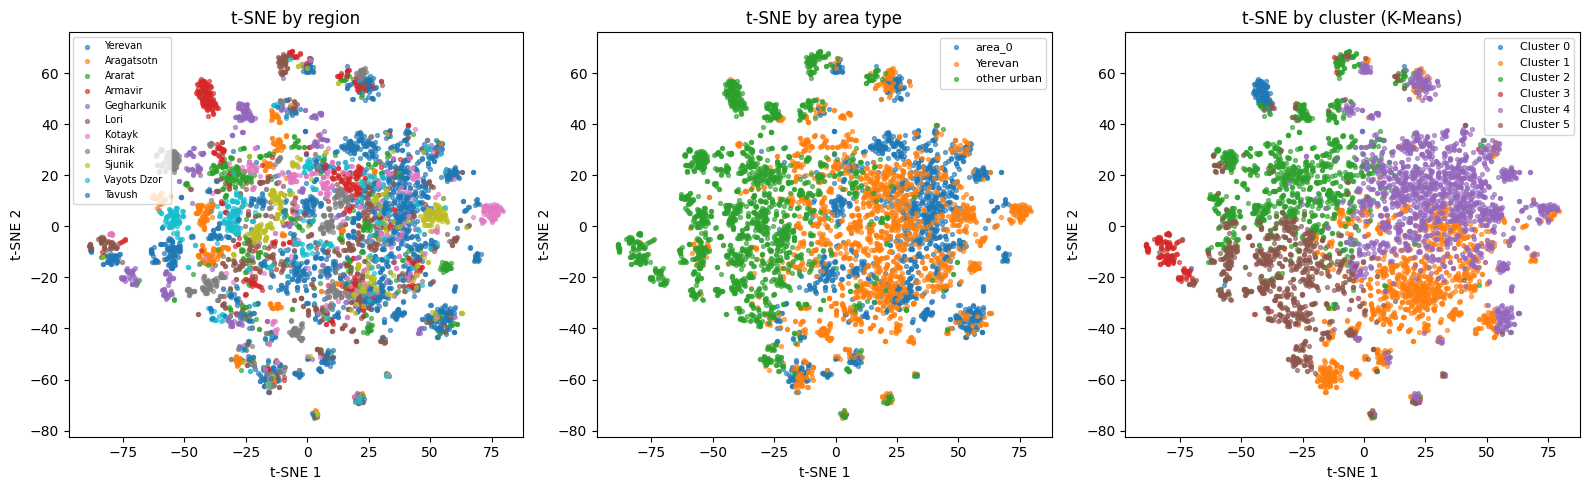

In [34]:
# Ensure region/area labels exist (e.g. if section 3 was skipped)
if "region_label" not in df.columns:
    def _value_label_map(var):
        sub = codebook[codebook["variable"] == var].copy()
        sub = sub[sub["value"].notna()]
        sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
        sub = sub.dropna(subset=["value_num"])
        sub["value_num"] = sub["value_num"].astype(int)
        return dict(zip(sub["value_num"], sub["value_label"].astype(str)))
    _region_map = _value_label_map("marz")
    _area_map = _value_label_map("typev")
    df["region_label"] = df["region"].map(lambda x: _region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
    df["area_type_label"] = df["area_type"].map(lambda x: _area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By region
ax = axes[0]
for label in df["region_label"].dropna().unique():
    mask = df["region_label"] == label
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=label, alpha=0.6, s=8)
ax.set_title("t-SNE by region")
ax.legend(loc="best", fontsize=7)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# By area type
ax = axes[1]
for label in df["area_type_label"].dropna().unique():
    mask = df["area_type_label"] == label
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=label, alpha=0.6, s=8)
ax.set_title("t-SNE by area type")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

# By cluster
ax = axes[2]
for c in sorted(df["cluster"].unique()):
    mask = df["cluster"] == c
    ax.scatter(df.loc[mask, "tsne_1"], df.loc[mask, "tsne_2"], label=f"Cluster {c}", alpha=0.6, s=8)
ax.set_title("t-SNE by cluster (K-Means)")
ax.legend(loc="best", fontsize=8)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")

plt.tight_layout()
plt.show()

## 8. Crosstab: cluster vs. region and area type

**What the tables are:** Each cell = number of households in that **cluster** (row) and that **region** or **area type** (column). So we see *where* each socioeconomic type lives.

**How to use them:** Identify clusters that are mostly Yerevan vs. mostly other regions; mostly urban vs. rural. Combine with **per-cluster summary statistics** (e.g. mean income, share with poverty benefit) to name the segments (e.g. "better-off urban," "poor regional") and report your findings.

In [35]:
# Ensure region/area labels exist (e.g. if section 3 was skipped)
if "region_label" not in df.columns:
    def _value_label_map(var):
        sub = codebook[codebook["variable"] == var].copy()
        sub = sub[sub["value"].notna()]
        sub["value_num"] = pd.to_numeric(sub["value"], errors="coerce")
        sub = sub.dropna(subset=["value_num"])
        sub["value_num"] = sub["value_num"].astype(int)
        return dict(zip(sub["value_num"], sub["value_label"].astype(str)))
    _region_map = _value_label_map("marz")
    _area_map = _value_label_map("typev")
    df["region_label"] = df["region"].map(lambda x: _region_map.get(int(x), f"region_{x}") if pd.notna(x) else "Unknown")
    df["area_type_label"] = df["area_type"].map(lambda x: _area_map.get(int(x), f"area_{x}") if pd.notna(x) else "Unknown")

print("Cluster vs region (counts):")
print(pd.crosstab(df["cluster"], df["region_label"]))
print("\nCluster vs area type (counts):")
print(pd.crosstab(df["cluster"], df["area_type_label"]))

Cluster vs region (counts):
region_label  Aragatsotn  Ararat  Armavir  Gegharkunik  Kotayk  Lori  Shirak  \
cluster                                                                        
0                      0       0       92            2       0     0       0   
1                     25      88       94           35      79   151     108   
2                    181     169       83          139      78   107     108   
3                      0       5        4           32       9    57       0   
4                     22      96      110           37     146   124      91   
5                     96      74       49           79      12   101     125   

region_label  Sjunik  Tavush  Vayots Dzor  Yerevan  
cluster                                             
0                  1       0            0        4  
1                106      38           31      524  
2                 86      84          133       26  
3                  1      40            1        0  
4            